# Logistic Regression – Perceptron Trick

The `Perceptron Trick` is an intuitive way to understand how **Logistic Regression** updates its weights.
It connects ideas from the **Perceptron algorithm** with **gradient descent**, helping visualize how
misclassified points influence the decision boundary.

---

## Recap: Logistic Regression Model

Logistic Regression predicts probabilities using the sigmoid function:

$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

where:

$$
z = \theta^T x
$$

The predicted class is obtained by applying a threshold (usually 0.5).

---

## What Is the Perceptron Trick?

The perceptron trick describes how:
- **Misclassified points pull the decision boundary**
- **Correctly classified points have little or no effect**
- Updates are proportional to the **error**

Instead of hard 0/1 updates (as in the perceptron algorithm),
logistic regression makes **smooth, probabilistic updates**.

---

## Loss Function Behind the Trick

Logistic Regression minimizes **log loss**:

$$
J(\theta) = - \sum_{i=1}^{m}
\left[
y^{(i)} \log(\hat{y}^{(i)}) +
(1 - y^{(i)}) \log(1 - \hat{y}^{(i)})
\right]
$$

This loss increases sharply for confident wrong predictions,
forcing the model to correct itself.

---

## Gradient Descent Update Rule

The gradient of the loss with respect to parameters is:

$$
\frac{\partial J}{\partial \theta}
= \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)}) x^{(i)}
$$

So the update rule becomes:

$$
\theta := \theta - \alpha (\hat{y} - y) x
$$

This is the **perceptron trick**.

---

## Why This Is Called the Perceptron Trick

Compare with the perceptron update:

$$
\theta := \theta + y x \quad \text{(only when misclassified)}
$$

Logistic Regression generalizes this by:
- Updating **every point**
- Scaling the update by **prediction error**
- Making learning **smooth and stable**

Misclassified points cause **large updates**  
Correctly classified points cause **small or near-zero updates**

---

## Intuition Behind the Trick

- If \( y = 1 \) and \( \hat{y} \approx 0 \) → large positive update  
- If \( y = 0 \) and \( \hat{y} \approx 1 \) → large negative update  
- If prediction is confident and correct → minimal update  

Thus:
> The decision boundary moves toward misclassified points.

---

## Key Insights

- Logistic Regression is a **soft version of the perceptron**
- Uses probabilities instead of hard decisions
- Always updates weights, but by different magnitudes
- Ensures smooth convergence via log loss

---

## Why This Matters

Understanding the perceptron trick helps you:
- Intuitively understand gradient descent in classification
- Visualize how decision boundaries move
- Connect classical ML (Perceptron) with modern optimization

---

## Summary

The perceptron trick explains Logistic Regression’s weight updates as
error-weighted corrections that pull the decision boundary toward
misclassified points. It bridges the gap between the perceptron algorithm
and probabilistic gradient-based learning.


In [1]:
%%capture
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

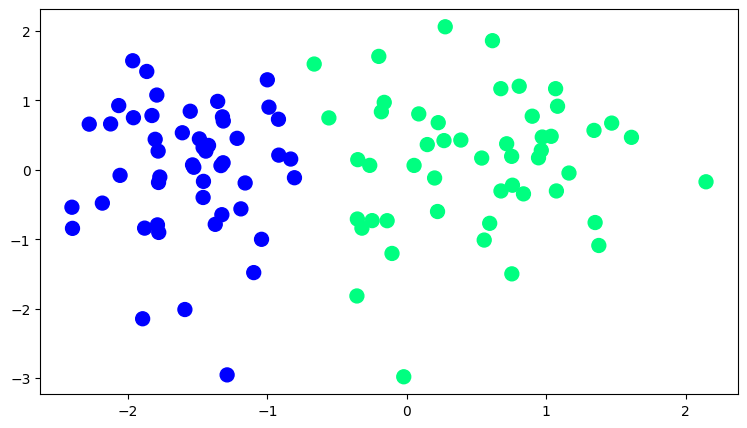

In [34]:
plt.figure(figsize=(9,5))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

### Perceptron Algorithm (Final Weights Only)

In [35]:
# Trains a perceptron model and returns the learned bias and weight vector after training.

def perceptron(X,y): 
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]
        

In [36]:
# Implements the threshold activation used in the Perceptron algorithm.

def step(z):
    return 1 if z>0 else 0

In [37]:
intercept_,coef_ = perceptron(X,y)

In [38]:
print(coef_)
print(intercept_)

[1.34578713 0.21302936]
1.0


In [39]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [40]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

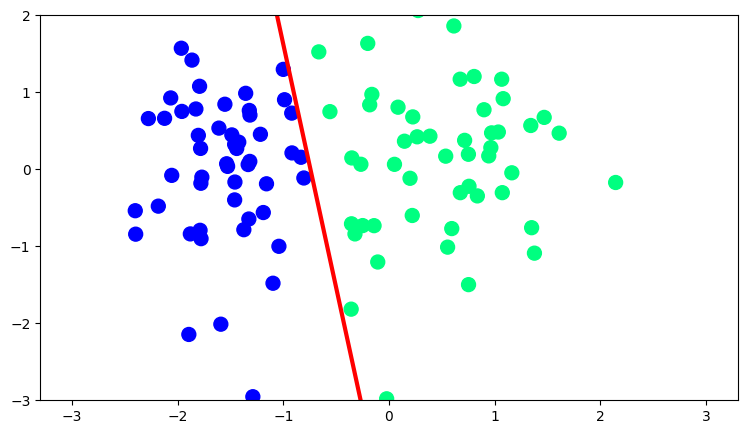

In [41]:
plt.figure(figsize=(9,5))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

### Perceptron Learning with Epoch-wise Decision Boundary Tracking

In [42]:
# Trains a perceptron model while storing slope (m) and intercept (b) at each iteration for visualization.

def perceptron(X,y):
    
    m = []
    b = []
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(200):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))
        
    return m,b

In [43]:
m,b = perceptron(X,y)

In [44]:
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

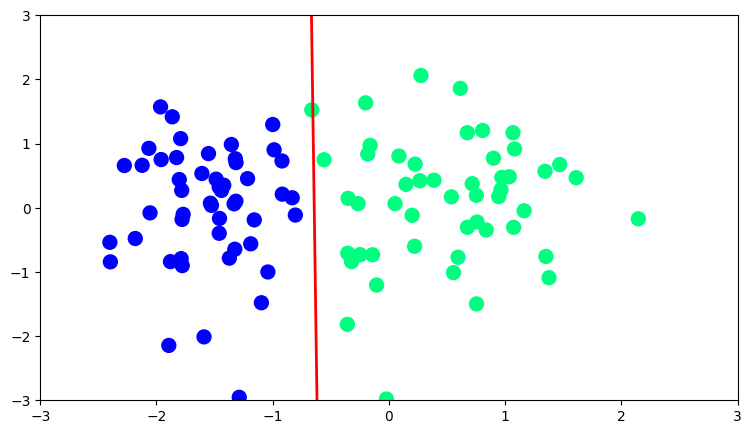

In [51]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)

ax.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)

# NO INDEXING
line, = ax.plot(x_i, m*x_i + b, 'r-', linewidth=2)

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)

plt.show()


### Scikit-Learn Built-in Logistic Regression Class¶

In [52]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [53]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

In [54]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

In [55]:
%matplotlib inline


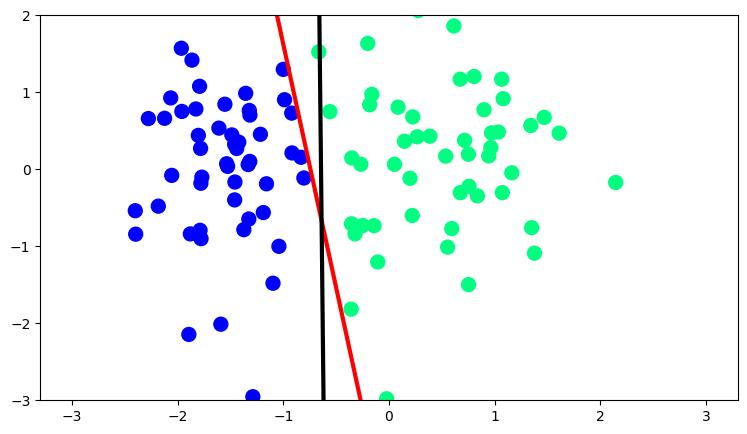

In [56]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9,5))

ax.plot(x_input, y_input, color='red', linewidth=3)
ax.plot(x_input1, y_input1, color='black', linewidth=3)

ax.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)

ax.set_ylim(-3, 2)

plt.show()
